#### initial setup

In [11]:
%pip install stable-baselines3
%pip install gymnasium-robotics

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import gymnasium_robotics
from stable_baselines3 import DDPG, TD3, SAC, HerReplayBuffer
from stable_baselines3.common.callbacks import BaseCallback

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## FetchReach-v4

#### function that periodically evaluates the policy and logs the progress metrics

In [17]:
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

print("Dependencies loaded and directories created.")

Dependencies loaded and directories created.


In [13]:
class CustomProgressCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=1000, n_eval_episodes=10, verbose=0):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_data = [] # Stores dictionary of {timestep, progress}

    def _on_step(self) -> bool:
        # check if it is time to evaluate
        if self.n_calls % self.eval_freq == 0:
            avg_progress = self._evaluate_progress()
            self.log_data.append({
                "timestep": self.num_timesteps, 
                "progress_percent": avg_progress * 100
            })
            
            if self.verbose > 0:
                print(f"Step {self.num_timesteps} | Eval Progress: {avg_progress * 100:.1f}%")
        return True

    def _evaluate_progress(self) -> float:
        progresses = []
        for _ in range(self.n_eval_episodes):
            obs, info = self.eval_env.reset()
            
            # capture initial distance at step 0
            initial_dist = np.linalg.norm(obs['achieved_goal'] - obs['desired_goal'])
            
            terminated, truncated = False, False
            while not (terminated or truncated):
                # use deterministic=True for pure greedy evaluation
                action, _ = self.model.predict(obs, deterministic=True)
                obs, _, terminated, truncated, _ = self.eval_env.step(action)
                
            # capture final distance when episode ends
            final_dist = np.linalg.norm(obs['achieved_goal'] - obs['desired_goal'])
            
            # calculate normalized progress
            prog = (initial_dist - final_dist) / (initial_dist + 1e-6)
            
            # floor at 0.0 so getting worse is the same as no progress
            prog = max(0.0, prog)
            progresses.append(prog)
            
        return float(np.mean(progresses))

    def save_log(self, filepath):
        # save the logged data to a CSV to plot later
        df = pd.DataFrame(self.log_data)
        df.to_csv(filepath, index=False)

#### training wrapper that handles evaluation during training

In [ ]:
def run_experiment(algo_class, algo_name, use_her, total_timesteps=5_000):
    env_id = "FetchReach-v4"
    experiment_name = f"{algo_name}_{'HER' if use_her else 'Baseline'}"
    print(f"\n--- Starting {experiment_name} ---")
    
    # create headless environments for speed
    train_env = gym.make(env_id, render_mode="none")
    eval_env = gym.make(env_id, render_mode="none")
    
    # configure HER Replay Buffer if requested
    if use_her:
        buffer_class = HerReplayBuffer
        buffer_kwargs = dict(n_sampled_goal=4, goal_selection_strategy="future")
    else:
        buffer_class = None # fall back to the algorithm's default buffer
        buffer_kwargs = None

    # initialize each algorithm
    model = algo_class(
        "MultiInputPolicy", 
        train_env,
        replay_buffer_class=buffer_class,
        replay_buffer_kwargs=buffer_kwargs,
        verbose=0,
        learning_rate=1e-3,
        policy_kwargs=dict(net_arch=[256, 256, 256])
    )
    
    # evaluate every 500 steps
    eval_callback = CustomProgressCallback(eval_env, eval_freq=500, n_eval_episodes=10, verbose=1)
    
    model.learn(total_timesteps=total_timesteps, callback=eval_callback)
    
    # save the model and the evaluation logs
    model.save(f"models/{experiment_name}")
    eval_callback.save_log(f"logs/{experiment_name}.csv")
    
    # clean up memory
    train_env.close()
    eval_env.close()
    print(f"Finished {experiment_name}.")

In [ ]:
# these are the ones testing for now
algorithms_to_test = {
    "DDPG": DDPG,
    "TD3": TD3,
    "SAC": SAC
}

# run each with and without HER
for name, algo in algorithms_to_test.items():
    for use_her in [False, True]:
        run_experiment(algo_class=algo, algo_name=name, use_her=use_her, total_timesteps=15_000)

print("\nAll training runs complete. Data saved to CSVs.")


--- Starting DDPG_Baseline ---


/Users/eric/miniforge3/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='none' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


Step 500 | Eval Progress: 0.0%
Step 1000 | Eval Progress: 0.0%
Step 1500 | Eval Progress: 0.0%
Step 2000 | Eval Progress: 0.0%
Step 2500 | Eval Progress: 0.0%
Step 3000 | Eval Progress: 0.0%
Step 3500 | Eval Progress: 0.0%
Step 4000 | Eval Progress: 0.0%
Step 4500 | Eval Progress: 0.0%
Step 5000 | Eval Progress: 0.0%
Step 5500 | Eval Progress: 0.0%
Step 6000 | Eval Progress: 0.0%
Step 6500 | Eval Progress: 0.0%
Step 7000 | Eval Progress: 0.0%
Step 7500 | Eval Progress: 0.0%
Step 8000 | Eval Progress: 0.0%
Step 8500 | Eval Progress: 0.0%
Step 9000 | Eval Progress: 0.0%
Step 9500 | Eval Progress: 0.0%
Step 10000 | Eval Progress: 0.0%
Step 10500 | Eval Progress: 0.0%
Step 11000 | Eval Progress: 0.0%
Step 11500 | Eval Progress: 0.0%
Step 12000 | Eval Progress: 0.0%
Step 12500 | Eval Progress: 0.0%
Step 13000 | Eval Progress: 0.0%
Step 13500 | Eval Progress: 0.0%
Step 14000 | Eval Progress: 0.0%
Step 14500 | Eval Progress: 0.0%
Step 15000 | Eval Progress: 0.0%
Finished DDPG_Baseline.

--- S

/Users/eric/miniforge3/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='none' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


Step 500 | Eval Progress: 0.0%
Step 1000 | Eval Progress: 0.0%
Step 1500 | Eval Progress: 0.0%
Step 2000 | Eval Progress: 0.0%
Step 2500 | Eval Progress: 0.0%
Step 3000 | Eval Progress: 1.7%
Step 3500 | Eval Progress: 17.7%
Step 4000 | Eval Progress: 46.9%
Step 4500 | Eval Progress: 59.2%
Step 5000 | Eval Progress: 69.4%
Step 5500 | Eval Progress: 87.5%
Step 6000 | Eval Progress: 86.3%
Step 6500 | Eval Progress: 72.4%
Step 7000 | Eval Progress: 84.3%
Step 7500 | Eval Progress: 70.4%
Step 8000 | Eval Progress: 76.6%
Step 8500 | Eval Progress: 84.7%
Step 9000 | Eval Progress: 80.6%
Step 9500 | Eval Progress: 56.5%
Step 10000 | Eval Progress: 74.2%
Step 10500 | Eval Progress: 76.9%
Step 11000 | Eval Progress: 75.1%
Step 11500 | Eval Progress: 78.1%
Step 12000 | Eval Progress: 82.7%
Step 12500 | Eval Progress: 82.9%
Step 13000 | Eval Progress: 75.2%
Step 13500 | Eval Progress: 85.8%
Step 14000 | Eval Progress: 78.0%
Step 14500 | Eval Progress: 85.3%
Step 15000 | Eval Progress: 86.7%
Finish

...

Step 500 | Eval Progress: 0.0%
Step 1000 | Eval Progress: 0.0%
Step 1500 | Eval Progress: 0.0%
Step 2000 | Eval Progress: 0.0%
Step 2500 | Eval Progress: 0.0%
Step 3000 | Eval Progress: 0.0%
Step 3500 | Eval Progress: 0.0%
Step 4000 | Eval Progress: 2.8%
Step 4500 | Eval Progress: 16.9%
Step 5000 | Eval Progress: 44.1%
Step 5500 | Eval Progress: 48.5%
Step 6000 | Eval Progress: 74.3%
Step 6500 | Eval Progress: 76.6%
Step 7000 | Eval Progress: 79.0%
Step 7500 | Eval Progress: 73.8%
Step 8000 | Eval Progress: 78.3%
Step 8500 | Eval Progress: 82.2%
Step 9000 | Eval Progress: 79.4%
Step 9500 | Eval Progress: 58.8%
Step 10000 | Eval Progress: 77.3%
Step 10500 | Eval Progress: 78.4%
Step 11000 | Eval Progress: 80.1%
Step 11500 | Eval Progress: 78.2%
Step 12000 | Eval Progress: 85.9%
Step 12500 | Eval Progress: 59.8%
Step 13000 | Eval Progress: 87.4%
Step 13500 | Eval Progress: 90.4%
Step 14000 | Eval Progress: 85.6%
Step 14500 | Eval Progress: 79.6%
Step 15000 | Eval Progress: 76.4%
Finished

/Users/eric/miniforge3/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='none' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


Step 500 | Eval Progress: 7.9%
Step 1000 | Eval Progress: 4.7%
Step 1500 | Eval Progress: 12.0%
Step 2000 | Eval Progress: 2.4%
Step 2500 | Eval Progress: 2.3%
Step 3000 | Eval Progress: 0.0%
Step 3500 | Eval Progress: 0.0%
Step 4000 | Eval Progress: 0.0%
Step 4500 | Eval Progress: 0.0%
Step 5000 | Eval Progress: 0.0%
Step 5500 | Eval Progress: 0.0%
Step 6000 | Eval Progress: 0.0%
Step 6500 | Eval Progress: 0.0%
Step 7000 | Eval Progress: 0.0%
Step 7500 | Eval Progress: 0.0%
Step 8000 | Eval Progress: 0.0%
Step 8500 | Eval Progress: 0.0%
Step 9000 | Eval Progress: 0.0%
Step 9500 | Eval Progress: 7.1%
Step 10000 | Eval Progress: 0.0%
Step 10500 | Eval Progress: 0.3%
Step 11000 | Eval Progress: 0.0%
Step 11500 | Eval Progress: 6.8%
Step 12000 | Eval Progress: 14.8%
Step 12500 | Eval Progress: 0.0%
Step 13000 | Eval Progress: 2.0%
Step 13500 | Eval Progress: 0.0%
Step 14000 | Eval Progress: 0.0%
Step 14500 | Eval Progress: 0.0%
Step 15000 | Eval Progress: 0.0%
Finished SAC_Baseline.

--- 

/Users/eric/miniforge3/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='none' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


Step 500 | Eval Progress: 8.2%
Step 1000 | Eval Progress: 0.4%
Step 1500 | Eval Progress: 0.0%
Step 2000 | Eval Progress: 6.9%
Step 2500 | Eval Progress: 1.7%
Step 3000 | Eval Progress: 0.0%
Step 3500 | Eval Progress: 0.0%
Step 4000 | Eval Progress: 37.8%
Step 4500 | Eval Progress: 45.8%
Step 5000 | Eval Progress: 65.4%
Step 5500 | Eval Progress: 76.3%
Step 6000 | Eval Progress: 71.2%
Step 6500 | Eval Progress: 67.8%
Step 7000 | Eval Progress: 88.2%
Step 7500 | Eval Progress: 87.1%
Step 8000 | Eval Progress: 92.5%
Step 8500 | Eval Progress: 88.7%
Step 9000 | Eval Progress: 83.8%
Step 9500 | Eval Progress: 80.1%
Step 10000 | Eval Progress: 91.2%
Step 10500 | Eval Progress: 79.4%
Step 11000 | Eval Progress: 89.2%
Step 11500 | Eval Progress: 9.6%
Step 12000 | Eval Progress: 88.0%
Step 12500 | Eval Progress: 88.8%
Step 13000 | Eval Progress: 81.4%
Step 13500 | Eval Progress: 80.6%
Step 14000 | Eval Progress: 82.4%
Step 14500 | Eval Progress: 86.0%
Step 15000 | Eval Progress: 86.7%
Finished

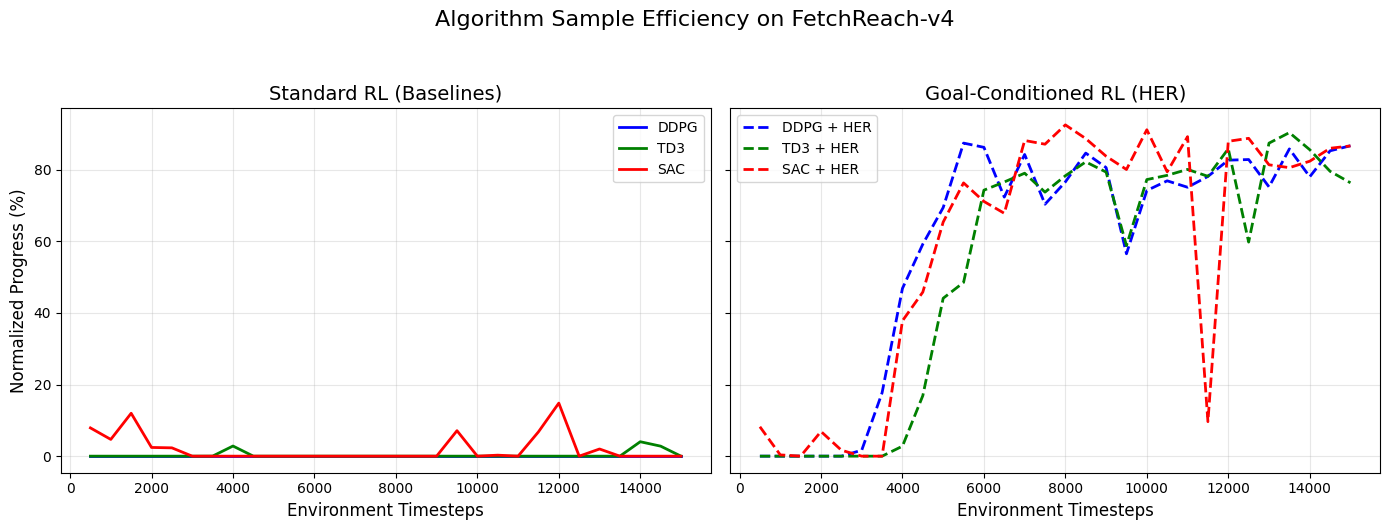

In [ ]:
def plot_learning_curves():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    colors = {"DDPG": "blue", "TD3": "green", "SAC": "red"}
    
    for name in colors.keys():
        # plot Baselines (Subplot 1)
        base_file = f"logs/{name}_Baseline.csv"
        if os.path.exists(base_file):
            df_base = pd.read_csv(base_file)
            ax1.plot(df_base["timestep"], df_base["progress_percent"], 
                     label=f"{name}", color=colors[name], linewidth=2)
            
        # Plot HER variants (Subplot 2)
        her_file = f"logs/{name}_HER.csv"
        if os.path.exists(her_file):
            df_her = pd.read_csv(her_file)
            ax2.plot(df_her["timestep"], df_her["progress_percent"], 
                     label=f"{name} + HER", color=colors[name], linestyle="--", linewidth=2)

    # formatting Subplot 1
    ax1.set_title("Standard RL (Baselines)", fontsize=14)
    ax1.set_xlabel("Environment Timesteps", fontsize=12)
    ax1.set_ylabel("Normalized Progress (%)", fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # formatting Subplot 2
    ax2.set_title("Goal-Conditioned RL (HER)", fontsize=14)
    ax2.set_xlabel("Environment Timesteps", fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.suptitle("Algorithm Sample Efficiency on FetchReach-v4", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_learning_curves()

### Baseline

### Baseline + HER

## FetchPush-v4

## FetchPickAndPlace-v4